**Гипотеза.** Новый подход к цене (на основе кластеризации, группа `test`) лучше традиционной оценки рисков (группа `control`).

**Метрики** (выбраны по влияющим факторам из задания):

| Фактор | Метрика | Тест |
|---|---|---|
| Конверсия | доля клиентов с оформленным полисом среди всех, кому показали цену | z-тест для двух долей |
| Цена | средняя цена оформленного полиса, руб. (+ цена за день, чтобы убрать эффект структуры поездок) | t-тест Уэлча |
| Убыточность | Loss Ratio = выплаты / премии; средняя выплата на полис | bootstrap-доверительный интервал; t-тест Уэлча |
| Итог | маржа на одного показанного клиента = (премия − выплаты) / все клиенты группы | t-тест Уэлча |

Курс USD/RUB = 80 (по условию).

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

try:
    from IPython.display import display
except ImportError:          # запуск вне Jupyter
    display = print

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.float_format", "{:,.2f}".format)

USD_RATE = 80          # курс доллара к рублю по условию задачи
ALPHA = 0.05           # уровень значимости
SEED = 42
rng = np.random.default_rng(SEED)

DATA_DIR = Path(".")

## 1. Загрузка данных и проверка качества

In [2]:
def read_xlsx(name):
    path = DATA_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Не найден файл {path.resolve()} - положите его рядом с ноутбуком или поправьте DATA_DIR")
    return pd.read_excel(path)

contracts = read_xlsx("CASE_CONTRACTS.xlsx")
losses = read_xlsx("CASE_LOSSES.xlsx")
clients = read_xlsx("CASE_CLIENTS.xlsx")          # в расчёте метрик не нужен, только для проверки
experiment_groups = read_xlsx("experiment_group.xlsx")

for name, frame in [("contracts", contracts), ("losses", losses),
                    ("clients", clients), ("experiment_groups", experiment_groups)]:
    print(f"{name}: {frame.shape}")
    na = frame.isna().sum()
    print("  пропуски:", na[na > 0].to_dict() or "нет")
    print("  типы:", frame.dtypes.astype(str).to_dict())

contracts: (3711, 10)
  пропуски: нет
  типы: {'contract_id': 'int64', 'contract_num': 'object', 'product_name': 'object', 'client_id': 'int64', 'contract_status': 'object', 'currency_name': 'object', 'duration': 'int64', 'country': 'object', 'price': 'int64', 'insurance_amount': 'int64'}
losses: (45, 4)
  пропуски: нет
  типы: {'loss_id': 'int64', 'client_id': 'int64', 'loss_name': 'object', 'loss_payout_amt': 'int64'}
clients: (3711, 6)
  пропуски: {'first_name': 18, 'middle_name': 258}
  типы: {'client_id': 'int64', 'last_name': 'object', 'first_name': 'object', 'middle_name': 'object', 'age': 'int64', 'sex': 'object'}
experiment_groups: (14842, 3)
  пропуски: {'group': 2493}
  типы: {'client_id': 'int64', 'group': 'object', 'experiment_id': 'object'}


In [3]:
# обязательные колонки и уникальность ключей, если что-то не так, ноутбук упадёт сразу и понятно
required = {
    "contracts": (contracts, ["contract_id", "client_id", "currency_name", "price", "duration"]),
    "losses": (losses, ["client_id", "loss_payout_amt"]),
    "experiment_groups": (experiment_groups, ["client_id", "group"]),
}
for name, (frame, cols) in required.items():
    missing = [c for c in cols if c not in frame.columns]
    assert not missing, f"В {name} нет колонок: {missing}"

assert experiment_groups["client_id"].is_unique, "Клиент попал в эксперимент несколько раз"
assert contracts["client_id"].is_unique, "У клиента несколько контрактов - нужна агрегация перед join"
assert losses["client_id"].is_unique, "У клиента несколько убытков - агрегируйте выплаты перед join"

# числовые поля должны быть числами (защита от строк вроде '1 200' после Excel)
for frame, cols in [(contracts, ["price", "duration"]), (losses, ["loss_payout_amt"])]:
    for c in cols:
        frame[c] = pd.to_numeric(frame[c], errors="coerce")

print("Валюты в контрактах:", contracts["currency_name"].value_counts(dropna=False).to_dict())
print("Группы в эксперименте:", experiment_groups["group"].value_counts(dropna=False).to_dict())
print("Контрактов с ценой <= 0 или без цены:", int((~(contracts["price"] > 0)).sum()))

Валюты в контрактах: {'Российский рубль': 3591, 'Доллар США': 120}
Группы в эксперименте: {'test': 6306, 'control': 6043, nan: 2493}
Контрактов с ценой <= 0 или без цены: 0


**Что важно в данных**

* В `experiment_group.xlsx` у части клиентов (~2,5 тыс.) **группа пустая** - они не участвовали в сравнении, их нужно исключить (иначе они «размоют» конверсию, если посчитать её по всем строкам).
* Цена и выплаты указаны в валюте контракта: для контрактов в USD умножаем на 80. Пропуск в выплате = убытка не было, то есть **0**, но только для оформленных контрактов.
* Клиенты без контракта: `price` и `currency_name` для них пустые - это НЕ ноль и не рубли, они просто не купили полис.

## 2. Сборка сводной таблицы

In [4]:
n_all = len(experiment_groups)
exp = experiment_groups[experiment_groups["group"].isin(["control", "test"])].copy()
print(f"Клиентов в эксперименте: {n_all}, из них с назначенной группой: {len(exp)} "
      f"(без группы исключено: {n_all - len(exp)})")

# left join: сохраняем ВСЕХ показанных клиентов, в том числе не купивших полис
df = exp.merge(contracts, on="client_id", how="left", validate="one_to_one")
df = df.merge(losses[["client_id", "loss_payout_amt"]], on="client_id", how="left", validate="one_to_one")

# признак оформления: есть contract_id
df["has_contract"] = df["contract_id"].notna().astype(int)

# убытки без контракта быть не должны
orphan = df[(df["has_contract"] == 0) & df["loss_payout_amt"].notna()]
print("Выплат у клиентов без контракта:", len(orphan))

# курс: только для USD-контрактов (у не купивших валюта пустая - остаётся NaN)
is_usd = df["currency_name"].eq("Доллар США")
rate = np.where(is_usd, USD_RATE, 1)
df["price_rub"] = df["price"] * rate                                   # NaN у не купивших - так и надо
df["loss_payout_rub"] = (df["loss_payout_amt"] * rate)                 # NaN = убытка нет
df.loc[df["has_contract"] == 1, "loss_payout_rub"] = df.loc[df["has_contract"] == 1, "loss_payout_rub"].fillna(0)
df["loss_payout_rub"] = df["loss_payout_rub"].fillna(0)                # у не купивших выплат тоже нет

# метрики «на одного показанного клиента»: нет полиса -> нет премии
df["premium_rub"] = df["price_rub"].fillna(0)
df["margin_rub"] = df["premium_rub"] - df["loss_payout_rub"]
df["price_per_day"] = df["price_rub"] / df["duration"]

# только оформленные контракты - для метрик цены и убыточности
df_contracts = df[df["has_contract"] == 1].copy()

print("\nИтоговый датасет:", df.shape, "| оформленных контрактов:", len(df_contracts))
assert df_contracts["price_rub"].notna().all() and (df_contracts["price_rub"] > 0).all()
display(df[["client_id", "group", "has_contract", "currency_name", "price", "price_rub", "loss_payout_rub"]].head())
display(df_contracts[["client_id", "group", "currency_name", "price", "price_rub", "loss_payout_amt", "loss_payout_rub"]]
        .query("loss_payout_rub > 0").head())

Клиентов в эксперименте: 14842, из них с назначенной группой: 12349 (без группы исключено: 2493)
Выплат у клиентов без контракта: 0

Итоговый датасет: (12349, 19) | оформленных контрактов: 3616


,client_id,group,has_contract,currency_name,price,price_rub,loss_payout_rub
0,10001718,control,1,Российский рубль,"3,836.00","3,836.00",0.00
1,1017180395,control,1,Российский рубль,"1,918.00","1,918.00",0.00
2,1017178047,control,1,Российский рубль,"3,836.00","3,836.00",0.00
3,1017174614,control,1,Российский рубль,"1,918.00","1,918.00",0.00
4,1017174071,control,1,Российский рубль,"1,096.00","1,096.00",0.00


,client_id,group,currency_name,price,price_rub,loss_payout_amt,loss_payout_rub
105,10139699711,control,Российский рубль,"1,918.00","1,918.00","250,000.00","250,000.00"
151,10000713193,control,Российский рубль,"1,644.00","1,644.00","100,000.00","100,000.00"
161,10006611194,control,Российский рубль,"1,644.00","1,644.00","70,000.00","70,000.00"
167,10006545463,control,Российский рубль,"1,644.00","1,644.00","30,000.00","30,000.00"
247,1860164119,control,Российский рубль,"3,836.00","3,836.00","700,000.00","700,000.00"


### Проверка корректности разбиения (SRM)

In [5]:
n_by_group = df["group"].value_counts().reindex(["control", "test"])
chi2, p_srm = stats.chisquare(n_by_group.values)      # ожидаем разбиение 50/50
print(n_by_group.to_dict(), f"| chi2 = {chi2:.3f}, p-value = {p_srm:.4f}")
if p_srm < ALPHA:
    print("ВНИМАНИЕ: размеры групп заметно отличаются от 50/50 (возможный sample ratio mismatch). "
          "Стоит уточнить у владельцев теста, как именно клиентов делили по группам.")

{'control': 6043, 'test': 6306} | chi2 = 5.601, p-value = 0.0179
ВНИМАНИЕ: размеры групп заметно отличаются от 50/50 (возможный sample ratio mismatch). Стоит уточнить у владельцев теста, как именно клиентов делили по группам.


## 3. Расчёт метрик

### 3.1 Конверсия в оформление

In [6]:
ctrl = df[df["group"] == "control"]
test = df[df["group"] == "test"]

n_c, n_t = len(ctrl), len(test)
x_c, x_t = ctrl["has_contract"].sum(), test["has_contract"].sum()
p_c, p_t = x_c / n_c, x_t / n_t

# z-тест для двух долей (объединённая доля в стандартной ошибке)
p_pool = (x_c + x_t) / (n_c + n_t)
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1 / n_c + 1 / n_t))
z_stat = (p_t - p_c) / se_pool
p_conv = 2 * (1 - stats.norm.cdf(abs(z_stat)))

# 95% ДИ разницы долей (непулированная SE)
se_diff = np.sqrt(p_c * (1 - p_c) / n_c + p_t * (1 - p_t) / n_t)
ci_conv = ((p_t - p_c) - 1.96 * se_diff, (p_t - p_c) + 1.96 * se_diff)

conv_table = pd.DataFrame({"клиентов": [n_c, n_t], "оформили": [x_c, x_t], "конверсия, %": [p_c * 100, p_t * 100]},
                          index=["control", "test"])
display(conv_table)
print(f"Разница (test - control): {(p_t - p_c) * 100:+.2f} п.п. "
      f"(95% ДИ: {ci_conv[0] * 100:+.2f} ... {ci_conv[1] * 100:+.2f}), относительно: {(p_t / p_c - 1) * 100:+.1f}%")
print(f"z = {z_stat:.3f}, p-value = {p_conv:.4f} -> {'значимо' if p_conv < ALPHA else 'не значимо'} на уровне {ALPHA}")

,клиентов,оформили,"конверсия, %"
control,6043,1949,32.25
test,6306,1667,26.44


Разница (test - control): -5.82 п.п. (95% ДИ: -7.42 ... -4.21), относительно: -18.0%
z = -7.101, p-value = 0.0000 -> значимо на уровне 0.05


### 3.2 Цена полиса

In [7]:
def welch(a, b, label):
    """t-тест Уэлча test vs control (без предположения о равенстве дисперсий)."""
    a, b = a.dropna(), b.dropna()
    t, p = stats.ttest_ind(a, b, equal_var=False)
    print(f"{label}: control = {b.mean():,.2f}, test = {a.mean():,.2f}, "
          f"diff = {a.mean() - b.mean():+,.2f} ({(a.mean() / b.mean() - 1) * 100:+.1f}%), t = {t:.3f}, p-value = {p:.4f} "
          f"-> {'значимо' if p < ALPHA else 'не значимо'}")
    return t, p

c_k = df_contracts[df_contracts["group"] == "control"]
t_k = df_contracts[df_contracts["group"] == "test"]

price_summary = df_contracts.groupby("group").agg(
    полисов=("price_rub", "size"),
    средняя_цена=("price_rub", "mean"),
    медиана_цены=("price_rub", "median"),
    средняя_длительность_дней=("duration", "mean"),
    цена_за_день=("price_per_day", "mean"),
)
display(price_summary)

t_price, p_price = welch(t_k["price_rub"], c_k["price_rub"], "Средняя цена полиса, руб.")
t_ppd, p_ppd = welch(t_k["price_per_day"], c_k["price_per_day"], "Средняя цена за день, руб.")
t_dur, p_dur = welch(t_k["duration"], c_k["duration"], "Длительность поездки, дней")

,полисов,средняя_цена,медиана_цены,средняя_длительность_дней,цена_за_день
group,,,,,
control,1949,"4,154.56","1,973.00",20.37,207.69
test,1667,"5,227.87","1,534.00",28.38,170.03


Средняя цена полиса, руб.: control = 4,154.56, test = 5,227.87, diff = +1,073.32 (+25.8%), t = 2.563, p-value = 0.0104 -> значимо
Средняя цена за день, руб.: control = 207.69, test = 170.03, diff = -37.65 (-18.1%), t = -13.494, p-value = 0.0000 -> значимо
Длительность поездки, дней: control = 20.37, test = 28.38, diff = +8.00 (+39.3%), t = 3.862, p-value = 0.0001 -> значимо


Цена в абсолютных рублях зависит от длительности и страны поездки, а состав купивших в группах разный. Поэтому средний чек нужно смотреть вместе с ценой за день и структурой поездок (см. вывод ниже).

### 3.3 Убыточность

In [8]:
def loss_ratio(frame):
    prem = frame["price_rub"].sum()
    return frame["loss_payout_rub"].sum() / prem if prem > 0 else np.nan

loss_table = df_contracts.groupby("group").agg(
    полисов=("price_rub", "size"),
    премия_руб=("price_rub", "sum"),
    выплаты_руб=("loss_payout_rub", "sum"),
    полисов_с_убытком=("loss_payout_rub", lambda x: int((x > 0).sum())),
    средняя_выплата_на_полис=("loss_payout_rub", "mean"),
)
loss_table["loss_ratio_%"] = loss_table["выплаты_руб"] / loss_table["премия_руб"] * 100
loss_table["частота_убытков_%"] = loss_table["полисов_с_убытком"] / loss_table["полисов"] * 100
display(loss_table)

# Loss ratio - отношение сумм, у него нет готового t-теста, поэтому bootstrap по полисам
def bootstrap_lr_diff(a, b, n_boot=5000):
    pa, la = a["price_rub"].to_numpy(), a["loss_payout_rub"].to_numpy()
    pb, lb = b["price_rub"].to_numpy(), b["loss_payout_rub"].to_numpy()
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        ia = rng.integers(0, len(pa), len(pa))
        ib = rng.integers(0, len(pb), len(pb))
        diffs[i] = la[ia].sum() / pa[ia].sum() - lb[ib].sum() / pb[ib].sum()
    return diffs

diffs = bootstrap_lr_diff(t_k, c_k)
lr_c, lr_t = loss_ratio(c_k), loss_ratio(t_k)
lo, hi = np.percentile(diffs, [2.5, 97.5])
print(f"Loss ratio: control = {lr_c * 100:.2f}%, test = {lr_t * 100:.2f}%, "
      f"разница = {(lr_t - lr_c) * 100:+.2f} п.п., bootstrap 95% ДИ: {lo * 100:+.2f} ... {hi * 100:+.2f} п.п.")
lr_significant = not (lo <= 0 <= hi)
print("-> различие", "значимо" if lr_significant else "НЕ значимо (ДИ включает 0)")

t_loss, p_loss = welch(t_k["loss_payout_rub"], c_k["loss_payout_rub"], "Средняя выплата на полис, руб.")

# частота убытков (доля полисов с выплатой) - точный тест Фишера, т.к. событий мало
ctab = [[int((t_k["loss_payout_rub"] > 0).sum()), int((t_k["loss_payout_rub"] == 0).sum())],
        [int((c_k["loss_payout_rub"] > 0).sum()), int((c_k["loss_payout_rub"] == 0).sum())]]
_, p_freq = stats.fisher_exact(ctab)
print(f"Частота убытков: control = {ctab[1][0] / len(c_k) * 100:.2f}%, test = {ctab[0][0] / len(t_k) * 100:.2f}%, "
      f"p-value (Фишер) = {p_freq:.4f}")

,полисов,премия_руб,выплаты_руб,полисов_с_убытком,средняя_выплата_на_полис,loss_ratio_%,частота_убытков_%
group,,,,,,,
control,1949,"8,097,229.00","6,380,000.00",30,"3,273.47",78.79,1.54
test,1667,"8,714,866.00","7,390,000.00",14,"4,433.11",84.80,0.84


Loss ratio: control = 78.79%, test = 84.80%, разница = +6.01 п.п., bootstrap 95% ДИ: -81.85 ... +105.00 п.п.
-> различие НЕ значимо (ДИ включает 0)
Средняя выплата на полис, руб.: control = 3,273.47, test = 4,433.11, diff = +1,159.64 (+35.4%), t = 0.502, p-value = 0.6157 -> не значимо
Частота убытков: control = 1.54%, test = 0.84%, p-value (Фишер) = 0.0672


### 3.4 Итоговая метрика: маржа на одного показанного клиента

In [9]:
# объединяет конверсию, цену и убыточность: (премия - выплаты) / все клиенты группы, включая не купивших
margin_summary = df.groupby("group").agg(
    клиентов=("client_id", "size"),
    премия_на_клиента=("premium_rub", "mean"),
    выплаты_на_клиента=("loss_payout_rub", "mean"),
    маржа_на_клиента=("margin_rub", "mean"),
)
display(margin_summary)

t_prem, p_prem = welch(test["premium_rub"], ctrl["premium_rub"], "Премия на показанного клиента, руб.")
t_marg, p_marg = welch(test["margin_rub"], ctrl["margin_rub"], "Маржа на показанного клиента, руб.")

,клиентов,премия_на_клиента,выплаты_на_клиента,маржа_на_клиента
group,,,,
control,6043,"1,339.94","1,055.77",284.17
test,6306,"1,382.00","1,171.90",210.10


Премия на показанного клиента, руб.: control = 1,339.94, test = 1,382.00, diff = +42.06 (+3.1%), t = 0.333, p-value = 0.7391 -> не значимо
Маржа на показанного клиента, руб.: control = 284.17, test = 210.10, diff = -74.07 (-26.1%), t = -0.114, p-value = 0.9095 -> не значимо


### 3.5 Визуализация

Цена за день у нас складывается из нескольких тарифных ступеней (≈55, 110, 164, 274 и 440 руб.), поэтому вместо boxplot показана структура полисов по ступеням: в test заметно больше полисов на дешёвых ступенях, в control - на ступени ≈274 руб./день.

tier,до 80 (~55),80-140 (~110),140-200 (~164),200-300 (~274),300+ (~440)
group,,,,,
control,0.00,26.80,23.20,47.90,2.10
test,6.30,49.50,11.00,30.70,2.60


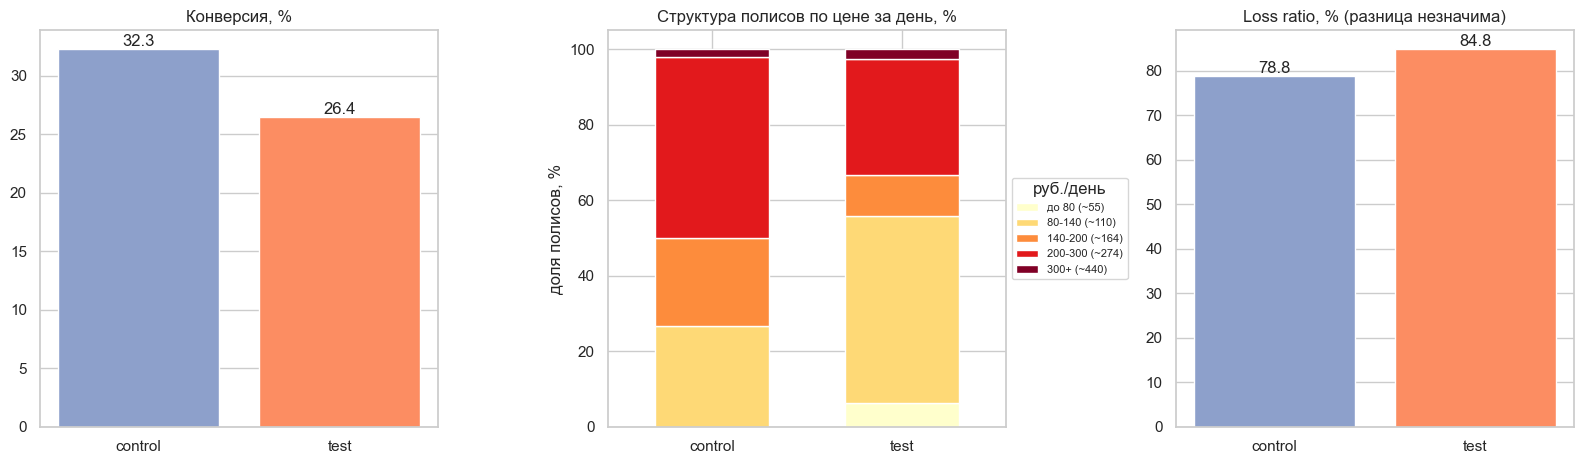

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
colors = ["#8da0cb", "#fc8d62"]

# 1) конверсия
axes[0].bar(["control", "test"], [p_c * 100, p_t * 100], color=colors)
axes[0].set_title("Конверсия, %")
for i, v in enumerate([p_c * 100, p_t * 100]):
    axes[0].text(i, v, f"{v:.1f}", ha="center", va="bottom")

# 2) структура полисов по дневному тарифу. Цена за день у нас дискретна (несколько тарифных ступеней),
#    поэтому boxplot тут неинформативен (квартили и медиана совпадают) - показываем доли полисов по ступеням
tier_bins = [0, 80, 140, 200, 300, np.inf]
tier_labels = ["до 80 (~55)", "80-140 (~110)", "140-200 (~164)", "200-300 (~274)", "300+ (~440)"]
df_contracts["tier"] = pd.cut(df_contracts["price_per_day"], bins=tier_bins, labels=tier_labels)
tier_share = (pd.crosstab(df_contracts["group"], df_contracts["tier"], normalize="index") * 100).reindex(["control", "test"])
tier_share.plot(kind="bar", stacked=True, ax=axes[1], colormap="YlOrRd", width=0.6, edgecolor="white")
axes[1].set_title("Структура полисов по цене за день, %")
axes[1].set_xlabel("")
axes[1].set_ylabel("доля полисов, %")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="руб./день", fontsize=8, loc="center left", bbox_to_anchor=(1.0, 0.5))

# 3) Loss ratio
axes[2].bar(["control", "test"], [lr_c * 100, lr_t * 100], color=colors)
axes[2].set_title("Loss ratio, % (разница незначима)")
for i, v in enumerate([lr_c * 100, lr_t * 100]):
    axes[2].text(i, v, f"{v:.1f}", ha="center", va="bottom")

for a in (axes[0], axes[2]):
    a.grid(axis="x", visible=False)          # вертикальные линии сетки не должны пересекать подписи столбцов
display(tier_share.round(1))

plt.tight_layout()
plt.show()

### 3.6 Сводная таблица

In [11]:
summary = pd.DataFrame([
    ("Конверсия, %",                 p_c * 100,                       p_t * 100,                       p_conv),
    ("Средняя цена полиса, руб.",    c_k["price_rub"].mean(),         t_k["price_rub"].mean(),         p_price),
    ("Цена за день, руб.",           c_k["price_per_day"].mean(),     t_k["price_per_day"].mean(),     p_ppd),
    ("Loss ratio, %",                lr_c * 100,                      lr_t * 100,                      np.nan),
    ("Выплата на полис, руб.",       c_k["loss_payout_rub"].mean(),   t_k["loss_payout_rub"].mean(),   p_loss),
    ("Маржа на показанного клиента, руб.", ctrl["margin_rub"].mean(), test["margin_rub"].mean(),       p_marg),
], columns=["Метрика", "control", "test", "p-value"])
summary["значимо (p<0.05)"] = np.where(summary["p-value"].isna(), "см. bootstrap ДИ",
                                        np.where(summary["p-value"] < ALPHA, "да", "нет"))
display(summary)

,Метрика,control,test,p-value,значимо (p<0.05)
0,"Конверсия, %",32.25,26.44,0.00,да
1,"Средняя цена полиса, руб.","4,154.56","5,227.87",0.01,да
2,"Цена за день, руб.",207.69,170.03,0.00,да
3,"Loss ratio, %",78.79,84.80,NaN,см. bootstrap ДИ
4,"Выплата на полис, руб.","3,273.47","4,433.11",0.62,нет
5,"Маржа на показанного клиента, руб.",284.17,210.10,0.91,нет


## 4. Бизнес-рекомендация

**Рекомендация: не внедрять новый подход к ценообразованию на весь портфель, оставить действующий (control).** Новый подход имеет смысл дорабатывать и перепроверить на более длинном тесте.

**Что подтвердил тест**

* **Конверсия упала значимо:** 32,25% → 26,44% (-5,8 п.п., около -18% относительно, p < 0,001). Это единственный устойчивый эффект теста, и он отрицательный: новая цена отпугивает больше клиентов.
* **Средний чек вырос значимо** (4 155 → 5 228 руб., p ≈ 0,01), но это в основном эффект структуры продаж, а не «более дорогая цена»: в test купили более длинные поездки (в среднем 28 против 20 дней) и другие направления. **Цена за день, наоборот, ниже** (≈170 против ≈208 руб., p < 0,001), а медиана чека в test тоже ниже (1 534 против 1 973 руб.). Учитывая ещё и то, что цену мы наблюдаем только у купивших (это уже отбор), считать рост чека выигрышем нельзя.

**Что тест НЕ подтвердил (важно для честного вывода)**

* **Убыточность:** 78,8% → 84,8% (+6 п.п.), но разница **статистически не значима** (bootstrap 95% ДИ для разницы - от -82 до +105 п.п., то есть чудовищно широкий и включает 0; t-тест по выплатам p ≈ 0,62). Частота убытков в test даже ниже (0,84% против 1,54%, тест Фишера p ≈ 0,07 - не значимо), а разница loss ratio целиком определяется несколькими крупными выплатами. Всего 44 убыточных случая на 3 616 полисов, поэтому тест просто не имеет мощности заметить разницу в выплатах. Утверждение о «неблагоприятной селекции» данными не доказано - это лишь гипотеза.
* **Итоговая маржа на показанного клиента** (~284 руб. в control против ~210 руб. в test) различается **незначимо** (p ≈ 0,91): при таком разбросе выплат нельзя утверждать, что новый подход зарабатывает ни больше, ни меньше.

**Позитивное влияние на бизнес (если бы эффект подтвердился):** больше премии с одного полиса, более гибкая цена под риск сегмента; премия на показанного клиента в test чуть выше (~1 382 против ~1 340 руб.), но незначимо.

**Негативное влияние:** потеря около 18% продаж (значимо), риск потерять долю рынка и клиентскую базу; убыточность не улучшилась (по точечной оценке стала хуже), а ценовой эффект нового подхода не дал выигрыша по марже.

**Итог:** нет статистически значимого улучшения ни по одной денежной метрике, зато есть значимое падение конверсии. Риск внедрения выше потенциальной выгоды. Предлагаю (1) оставить старую цену, (2) продолжить тест или увеличить выборку, чтобы оценить убыточность (выплаты редкие), (3) проверить корректность разбиения групп (размеры 6 043 и 6 306 отличаются от 50/50, p ≈ 0,02), (4) пересмотреть коэффициенты кластеров, у которых цена выросла сильнее всего.

**Ограничения анализа:** маржа не учитывает комиссии и расходы на ведение; часть контрактов ещё действует, поэтому выплаты могут вырасти; выплаты в USD-контрактах считаются в валюте контракта; распределение цен и выплат сильно скошено, поэтому t-тест здесь ориентировочный (для цены дополнительно подтверждается тестом Манна-Уитни).

In [12]:
# дополнительная проверка для скошенной цены: непараметрический тест (подтверждает t-тест)
u, p_u = stats.mannwhitneyu(t_k["price_rub"], c_k["price_rub"], alternative="two-sided")
print(f"Манн-Уитни для цены полиса: U = {u:,.0f}, p-value = {p_u:.4g} "
      "(медиана в test ниже, средняя выше - типичный признак разного состава поездок и скошенности)")

Манн-Уитни для цены полиса: U = 1,405,680, p-value = 1.397e-12 (медиана в test ниже, средняя выше - типичный признак разного состава поездок и скошенности)
